Import Dataset (Downloaded by Kaggle Datasets from Shubham Bathwal)

In [3]:
import pandas as pd
from google.colab import files
uploaded = files.upload()  # Upload Clean_Dataset.csv
data = pd.read_csv('Clean_Dataset.csv')

Saving Clean_Dataset.csv to Clean_Dataset (1).csv


Exploratory Data Analysis (EDA)

In [4]:
print('=== INFO DATASET ===')
print(data.info())
print('\n=== STATISTIK DESKRIPTIF ===')
print(data.describe())
print('\n=== MISSING VALUES ===')
print(data.isnull().sum())
print('\n=== DUPLIKAT ===')
print(f'Jumlah baris duplikat: {data.duplicated().sum()}')

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None

=== STATISTIK DESKRIPTIF ===
          Unnamed: 0       duration      days_left          price
count  300153.000000  300153.000

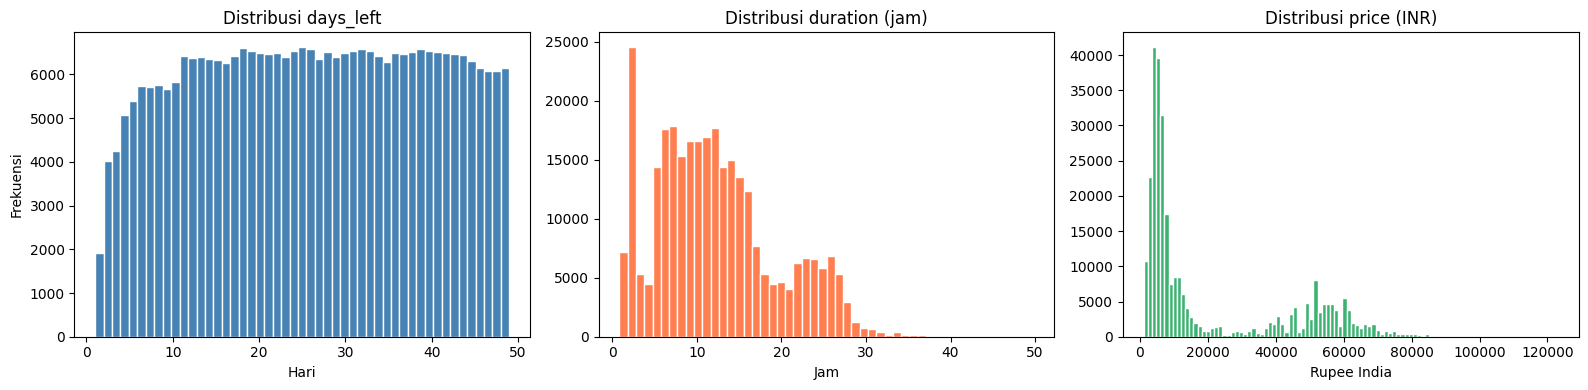

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# days_left
axes[0].hist(data['days_left'], bins=49, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi days_left')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Frekuensi')

# duration
axes[1].hist(data['duration'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribusi duration (jam)')
axes[1].set_xlabel('Jam')

# price
axes[2].hist(data['price'], bins=100, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Distribusi price (INR)')
axes[2].set_xlabel('Rupee India')

plt.tight_layout()
plt.savefig('eda_distribusi_numerik.png', dpi=150)
plt.show()

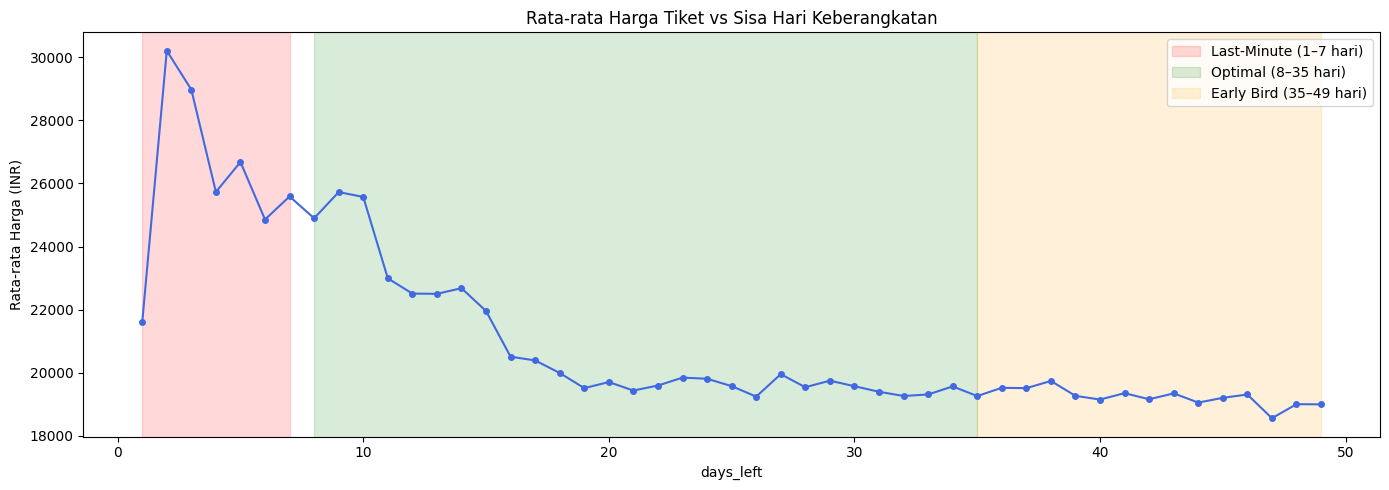

In [6]:
# ── 3.3 Analisis days_left vs rata-rata harga ─────────────────
avg_price_by_day = data.groupby('days_left')['price'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(avg_price_by_day['days_left'], avg_price_by_day['price'],
         marker='o', ms=4, color='royalblue', linewidth=1.5)
plt.axvspan(1, 7, alpha=0.15, color='red', label='Last-Minute (1–7 hari)')
plt.axvspan(8, 35, alpha=0.15, color='green', label='Optimal (8–35 hari)')
plt.axvspan(35, 49, alpha=0.15, color='orange', label='Early Bird (35–49 hari)')
plt.title('Rata-rata Harga Tiket vs Sisa Hari Keberangkatan')
plt.xlabel('days_left')
plt.ylabel('Rata-rata Harga (INR)')
plt.legend()
plt.tight_layout()
plt.savefig('eda_days_left_vs_price.png', dpi=150)
plt.show()

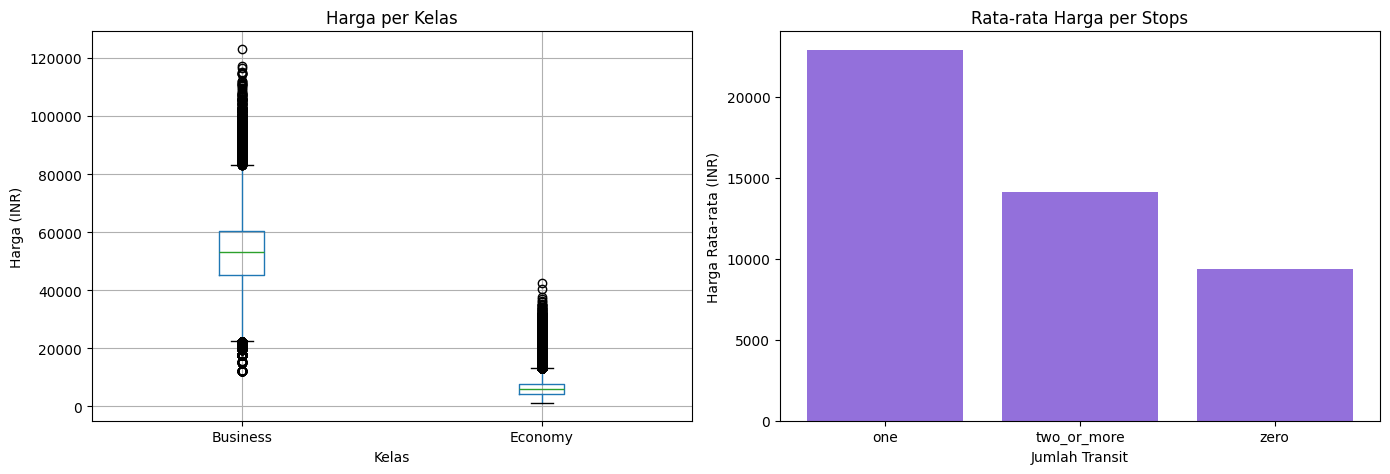

In [12]:
# ── 3.4 Harga berdasarkan class & stops ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot per class
data.boxplot(column='price', by='class', ax=axes[0])
axes[0].set_title('Harga per Kelas')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Harga (INR)')

# === Bagian Bar Chart yang disederhanakan ===
# 1. Hitung nilai rata-rata harga untuk setiap 'stops' (jumlah transit)
rata_rata_harga = data.groupby('stops')['price'].mean()

# 2. Buat bar chart secara langsung dari hasil rata-rata di atas
# rata_rata_harga.index berisi nama kategori ('zero', 'one', 'two_or_more')
# rata_rata_harga.values berisi angka rata-rata harganya
axes[1].bar(rata_rata_harga.index, rata_rata_harga.values, color='mediumpurple')
# ============================================

axes[1].set_title('Rata-rata Harga per Stops')
axes[1].set_xlabel('Jumlah Transit')
axes[1].set_ylabel('Harga Rata-rata (INR)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_class_stops.png', dpi=150)
plt.show()

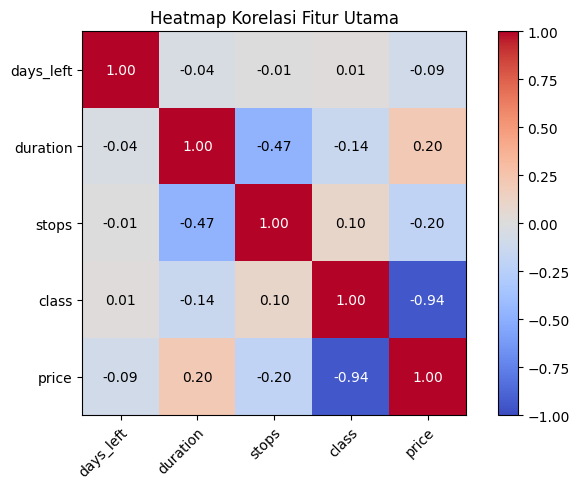

In [15]:
# ── 3.5 Heatmap korelasi ──────────────────────────────────────
# Encode variabel kategorik untuk korelasi
from sklearn.preprocessing import LabelEncoder
data_corr = data.copy()
le = LabelEncoder()
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ── 3.5 Heatmap korelasi ──────────────────────────────────────
# Encode variabel kategorik untuk korelasi
data_corr = data.copy()
le = LabelEncoder()
for col in ['airline', 'source_city', 'departure_time',
             'stops', 'arrival_time', 'destination_city', 'class']:
    if col in data_corr.columns:
        data_corr[col] = le.fit_transform(data_corr[col].astype(str))

corr_cols = ['days_left', 'duration', 'stops', 'class', 'price']
corr_matrix = data_corr[corr_cols].corr()

# === Membuat Heatmap menggunakan Matplotlib ===
fig, ax = plt.subplots(figsize=(7, 5))

# 1. Menampilkan matriks warna
cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# 2. Menambahkan skala warna (colorbar) di samping
fig.colorbar(cax)

# 3. Mengatur posisi dan label pada sumbu X dan Y
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols)
ax.set_yticklabels(corr_cols)

# Putar sedikit label sumbu X agar tidak saling menumpuk
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# 4. Menambahkan angka (anotasi) di dalam kotak
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        nilai = corr_matrix.iloc[i, j]
        # Jika warnanya terlalu gelap/pekat, gunakan teks putih. Jika terang, teks hitam.
        warna_teks = "white" if (nilai > 0.5 or nilai < -0.5) else "black"
        ax.text(j, i, f"{nilai:.2f}", ha="center", va="center", color=warna_teks)

plt.title('Heatmap Korelasi Fitur Utama')
plt.tight_layout()
plt.savefig('eda_heatmap_korelasi.png', dpi=150)
plt.show()

## 🛠️ 4. Pra-pemrosesan & Pembuatan Label Ground Truth

In [18]:
# ── 4.1 Hapus duplikat & missing values ───────────────────────
data_clean = data.drop_duplicates().dropna().reset_index(drop=True)
print(f'Shape setelah pembersihan: {data_clean.shape}')

# ── 4.2 Encode stops → numerik ────────────────────────────────
stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
data_clean['stops_num'] = data_clean['stops'].map(stops_map)

# ── 4.3 Encode class → biner ──────────────────────────────────
data_clean['class_num'] = (data_clean['class'] == 'Business').astype(int)

# ── 4.4 Normalisasi harga per kelas (price_ratio) ─────────────
# Price ratio: posisi harga relatif dalam distribusi kelasnya (0–1)
def compute_price_ratio(group):
    p_min = group['price'].min()
    p_max = group['price'].max()
    group = group.copy()
    group['price_ratio'] = (group['price'] - p_min) / (p_max - p_min + 1e-9)
    return group

data_clean = data_clean.groupby('class', group_keys=False).apply(compute_price_ratio)

# ── 4.5 Label Ground Truth (binning persentil per kelas) ───────
def assign_label(group):
    p33 = group['price'].quantile(0.33)
    p67 = group['price'].quantile(0.67)
    group = group.copy()
    group['label'] = group['price'].apply(
        lambda p: 0 if p <= p33 else (2 if p >= p67 else 1)
    )  # 0=Beli Sekarang, 1=Pertimbangkan, 2=Tunggu
    return group

data_clean = data_clean.groupby('class', group_keys=False).apply(assign_label)
label_names = {0: 'Beli Sekarang', 1: 'Pertimbangkan', 2: 'Tunggu'}

print('\nDistribusi label ground truth:')
print(data_clean['label'].value_counts().rename(label_names))

# ── 4.6 Subsampel 10.000 untuk eksperimen FIS ─────────────────
data_sample = data_clean.sample(n=10000, random_state=42).reset_index(drop=True)
print(f'\nSubsampel shape: {data_sample.shape}')

Shape setelah pembersihan: (300153, 12)


/tmp/ipykernel_3607/2200871739.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_clean = data_clean.groupby('class', group_keys=False).apply(compute_price_ratio)



Distribusi label ground truth:
label
Pertimbangkan    101090
Beli Sekarang     99997
Tunggu            99066
Name: count, dtype: int64

Subsampel shape: (10000, 16)


/tmp/ipykernel_3607/2200871739.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_clean = data_clean.groupby('class', group_keys=False).apply(assign_label)


In [20]:
# ── 4.7 Train/Val/Test Split (8:1:1) MANUAL TANPA SKLEARN ─────
# List untuk menampung potongan data
train_list, val_list, test_list = [], [], []
# Group berdasarkan 'label' supaya pembagian kelasnya adil (Stratified)
for label, group in data_sample.groupby('label'):
    # Acak baris data di dalam kelompok label ini
    group_shuffled = group.sample(frac=1, random_state=42)

    # Hitung jumlah baris untuk rasio 8:1:1
    n = len(group_shuffled)
    idx_train = int(0.8 * n)          # Batas akhir untuk Train (80%)
    idx_val = idx_train + int(0.1 * n) # Batas akhir untuk Val (10%)

    # Potong data dan masukkan ke list masing-masing
    train_list.append(group_shuffled.iloc[:idx_train])
    val_list.append(group_shuffled.iloc[idx_train:idx_val])
    test_list.append(group_shuffled.iloc[idx_val:])

# Gabungkan kembali semua potongan kelompok data dan acak ulang posisinya
df_train = pd.concat(train_list).sample(frac=1, random_state=42)
df_val = pd.concat(val_list).sample(frac=1, random_state=42)
df_test = pd.concat(test_list).sample(frac=1, random_state=42)

# Definisikan kolom fitur yang ingin diambil
fitur_cols = ['days_left', 'price_ratio', 'duration', 'stops_num']

# Ubah menjadi format matriks (.values) sesuai kebutuhan variabel aslimu
X_train, y_train = df_train[fitur_cols].values, df_train['label'].values
X_val, y_val = df_val[fitur_cols].values, df_val['label'].values
X_test, y_test = df_test[fitur_cols].values, df_test['label'].values

# Cetak hasil pembagian baris data
print(f'Train : {X_train.shape[0]} baris')
print(f'Val   : {X_val.shape[0]} baris')
print(f'Test  : {X_test.shape[0]} baris')

Train : 7999 baris
Val   : 998 baris
Test  : 1003 baris


## 🧠 5. Desain & Implementasi FIS (Mamdani)

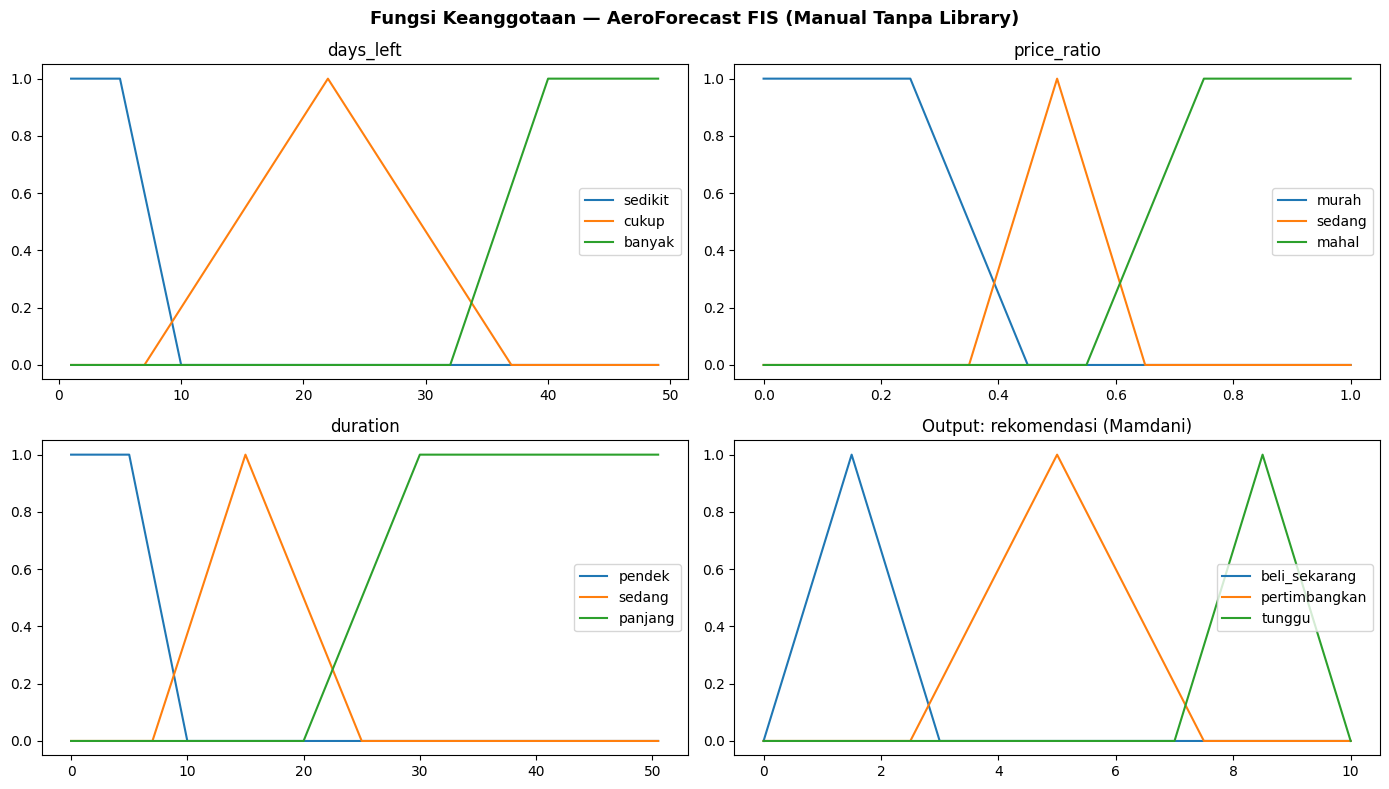

In [22]:
# ════════════════════════════════════════════════════════════════
#  5A. FIS MAMDANI (MANUAL TANPA LIBRARY SKFUZZY)
# ════════════════════════════════════════════════════════════════

# ── 1. Membuat Fungsi Keanggotaan (Membership Function) ────────
def trimf(x, abc):
    """Fungsi untuk membuat kurva Segitiga (Triangular)"""
    a, b, c = abc
    y = np.zeros_like(x, dtype=float)
    # Sisi kiri (garis naik)
    if a != b:
        idx = (x > a) & (x <= b)
        y[idx] = (x[idx] - a) / (b - a)
    # Sisi kanan (garis turun)
    if b != c:
        idx = (x > b) & (x < c)
        y[idx] = (c - x[idx]) / (c - b)
    # Titik puncak
    y[x == b] = 1.0
    return y

def trapmf(x, abcd):
    """Fungsi untuk membuat kurva Trapesium (Trapezoidal)"""
    a, b, c, d = abcd
    y = np.zeros_like(x, dtype=float)
    # Sisi kiri (garis naik)
    if a != b:
        idx = (x > a) & (x < b)
        y[idx] = (x[idx] - a) / (b - a)
    # Bagian atas (rata/datar)
    idx_top = (x >= b) & (x <= c)
    y[idx_top] = 1.0
    # Sisi kanan (garis turun)
    if c != d:
        idx2 = (x > c) & (x < d)
        y[idx2] = (d - x[idx2]) / (d - c)
    return y

# ── 2. Variabel Semesta (Universe) ───────────────────────────
x_days_left   = np.arange(1, 50, 1)
x_price_ratio = np.arange(0, 1.01, 0.01)
x_duration    = np.arange(0, 51, 0.5)
x_rekomendasi = np.arange(0, 10.1, 0.1)

# ── 3. Menghitung Nilai Keanggotaan per Kategori ─────────────
# days_left
days_sedikit = trapmf(x_days_left, [1, 1, 5, 10])
days_cukup   = trimf(x_days_left, [7, 22, 37])
days_banyak  = trapmf(x_days_left, [32, 40, 49, 49])

# price_ratio
price_murah  = trapmf(x_price_ratio, [0, 0, 0.25, 0.45])
price_sedang = trimf(x_price_ratio, [0.35, 0.5, 0.65])
price_mahal  = trapmf(x_price_ratio, [0.55, 0.75, 1.0, 1.0])

# duration
dur_pendek  = trapmf(x_duration, [0, 0, 5, 10])
dur_sedang  = trimf(x_duration, [7, 15, 25])
dur_panjang = trapmf(x_duration, [20, 30, 51, 51])

# output: rekomendasi
rek_beli_sekarang = trimf(x_rekomendasi, [0, 1.5, 3])
rek_pertimbangkan = trimf(x_rekomendasi, [2.5, 5, 7.5])
rek_tunggu        = trimf(x_rekomendasi, [7, 8.5, 10])

# ── 4. Visualisasi Fungsi Keanggotaan ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Plot days_left
axes[0, 0].plot(x_days_left, days_sedikit, label='sedikit')
axes[0, 0].plot(x_days_left, days_cukup, label='cukup')
axes[0, 0].plot(x_days_left, days_banyak, label='banyak')
axes[0, 0].set_title('days_left')
axes[0, 0].legend()

# Plot price_ratio
axes[0, 1].plot(x_price_ratio, price_murah, label='murah')
axes[0, 1].plot(x_price_ratio, price_sedang, label='sedang')
axes[0, 1].plot(x_price_ratio, price_mahal, label='mahal')
axes[0, 1].set_title('price_ratio')
axes[0, 1].legend()

# Plot duration
axes[1, 0].plot(x_duration, dur_pendek, label='pendek')
axes[1, 0].plot(x_duration, dur_sedang, label='sedang')
axes[1, 0].plot(x_duration, dur_panjang, label='panjang')
axes[1, 0].set_title('duration')
axes[1, 0].legend()

# Plot Output
axes[1, 1].plot(x_rekomendasi, rek_beli_sekarang, label='beli_sekarang')
axes[1, 1].plot(x_rekomendasi, rek_pertimbangkan, label='pertimbangkan')
axes[1, 1].plot(x_rekomendasi, rek_tunggu, label='tunggu')
axes[1, 1].set_title('Output: rekomendasi (Mamdani)')
axes[1, 1].legend()

plt.suptitle('Fungsi Keanggotaan — AeroForecast FIS (Manual Tanpa Library)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fis_membership_functions_manual.png', dpi=150)
plt.show()

In [36]:
# ════════════════════════════════════════════════════════════════
#  5B. EVALUASI ATURAN & DEFUZZIFIKASI MAMDANI (MANUAL)
# ════════════════════════════════════════════════════════════════

def prediksi_fis_mamdani(dl_val, pr_val, dur_val):
    """
    Fungsi manual untuk menghitung output Mamdani berdasarkan input crisp.
    Menggunakan variabel semesta dan kurva keanggotaan dari langkah 5A.
    """
    # 1. FUZZIFIKASI: Cari derajat keanggotaan menggunakan interpolasi linear (np.interp)
    mu_dl_sedikit = np.interp(dl_val, x_days_left, days_sedikit)
    mu_dl_cukup   = np.interp(dl_val, x_days_left, days_cukup)
    mu_dl_banyak  = np.interp(dl_val, x_days_left, days_banyak)

    mu_pr_murah   = np.interp(pr_val, x_price_ratio, price_murah)
    mu_pr_sedang  = np.interp(pr_val, x_price_ratio, price_sedang)
    mu_pr_mahal   = np.interp(pr_val, x_price_ratio, price_mahal)

    mu_dur_pendek  = np.interp(dur_val, x_duration, dur_pendek)
    mu_dur_sedang  = np.interp(dur_val, x_duration, dur_sedang)
    mu_dur_panjang = np.interp(dur_val, x_duration, dur_panjang)

    # Tempat menampung kekuatan aktifasi aturan (Fuzzy AND = min)
    r_tunggu = []
    r_pertimbangkan = []
    r_beli = []

    # ── EVALUASI ATURAN (Sesuai dengan isi kode lamamu) ──
    # days_left = sedikit
    r_tunggu.append(min(mu_dl_sedikit, mu_pr_mahal))
    r_tunggu.append(min(mu_dl_sedikit, mu_pr_sedang))
    r_pertimbangkan.append(min(mu_dl_sedikit, mu_pr_murah))

    # days_left = cukup
    r_beli.append(min(mu_dl_cukup, mu_pr_murah))
    r_pertimbangkan.append(min(mu_dl_cukup, mu_pr_sedang))
    r_tunggu.append(min(mu_dl_cukup, mu_pr_mahal))

    # days_left = banyak
    r_beli.append(min(mu_dl_banyak, mu_pr_murah))
    r_pertimbangkan.append(min(mu_dl_banyak, mu_pr_sedang))
    r_tunggu.append(min(mu_dl_banyak, mu_pr_mahal))

    # Aturan tambahan melibatkan duration
    r_beli.append(min(mu_dl_cukup, mu_pr_murah, mu_dur_pendek))
    r_tunggu.append(min(mu_dl_cukup, mu_pr_mahal, mu_dur_panjang))

    # 2. AGREGASI OUTPUT (Mencari nilai MAX untuk masing-masing konsekuen)
    w_tunggu        = max(r_tunggu) if r_tunggu else 0.0
    w_pertimbangkan = max(r_pertimbangkan) if r_pertimbangkan else 0.0
    w_beli          = max(r_beli) if r_beli else 0.0

    # Memotong kurva output rekomendasi dengan bobot aturan (Mamdani Implication)
    area_beli          = np.minimum(w_beli, rek_beli_sekarang)
    area_pertimbangkan = np.minimum(w_pertimbangkan, rek_pertimbangkan)
    area_tunggu        = np.minimum(w_tunggu, rek_tunggu)

    # Menggabungkan seluruh area output menjadi satu kesatuan kurva
    kurva_akhir = np.maximum(area_beli, np.maximum(area_pertimbangkan, area_tunggu))

    # 3. DEFUZZIFIKASI: Menggunakan Metode COA (Centroid / Center of Area)
    total_area = np.sum(kurva_akhir)
    if total_area == 0:
        return 5.0  # Nilai default (tengah) jika tidak ada aturan yang terpenuhi

    nilai_crisp = np.sum(x_rekomendasi * kurva_akhir) / total_area
    return nilai_crisp

print('✅ Fungsi simulasi & Rule base Mamdani (Manual) berhasil dibuat!')

# ── Contoh Cara Mengujinya ────────────────────────────────────
# Tes memasukkan data: days_left=3, price_ratio=0.85, duration=12
hasil_tes = prediksi_fis_mamdani(dl_val=3, pr_val=0.85, dur_val=12)
print(f'Hasil rekomendasi skor untuk data uji: {hasil_tes:.2f}')

✅ Fungsi simulasi & Rule base Mamdani (Manual) berhasil dibuat!
Hasil rekomendasi skor untuk data uji: 8.50


## 🧠 5. Desain & Implementasi FIS (Sugeno)

In [37]:
# ════════════════════════════════════════════════════════════════
#  5B. FIS SUGENO (implementasi manual)
# ════════════════════════════════════════════════════════════════

def gaussian_mf(x, c, sigma):
    """Fungsi keanggotaan Gaussian."""
    return np.exp(-((x - c) ** 2) / (2 * sigma ** 2))

def trimf_manual(x, a, b, c):
    """Fungsi keanggotaan segitiga."""
    return np.maximum(0, np.minimum((x - a) / (b - a + 1e-9),
                                    (c - x) / (c - b + 1e-9)))

def trapmf_manual(x, a, b, c, d):
    """Fungsi keanggotaan trapesoid."""
    return np.maximum(0, np.minimum(
        np.minimum((x - a) / (b - a + 1e-9), 1),
        (d - x) / (d - c + 1e-9)
    ))

def sugeno_infer(days_left_val, price_ratio_val, duration_val):
    """
    FIS Sugeno: output berupa nilai crisp (weighted average of singleton outputs).
    Output: 0=Beli Sekarang, 1=Pertimbangkan, 2=Tunggu
    """
    # Fuzzifikasi days_left
    dl_sedikit = float(trapmf_manual(days_left_val, 1, 1, 5, 10))
    dl_cukup   = float(trimf_manual(days_left_val, 7, 22, 37))
    dl_banyak  = float(trapmf_manual(days_left_val, 32, 40, 49, 49))

    # Fuzzifikasi price_ratio
    pr_murah  = float(trapmf_manual(price_ratio_val, 0, 0, 0.25, 0.45))
    pr_sedang = float(trimf_manual(price_ratio_val, 0.35, 0.5, 0.65))
    pr_mahal  = float(trapmf_manual(price_ratio_val, 0.55, 0.75, 1.0, 1.0))

    # Fuzzifikasi duration
    dur_pendek  = float(trapmf_manual(duration_val, 0, 0, 5, 10))
    dur_panjang = float(trapmf_manual(duration_val, 20, 30, 51, 51))

    # Singleton outputs: 0=Beli, 1=Pertimbangkan, 2=Tunggu
    rules = [
        (min(dl_sedikit, pr_mahal),  2.0),
        (min(dl_sedikit, pr_sedang), 2.0),
        (min(dl_sedikit, pr_murah),  1.0),
        (min(dl_cukup,   pr_murah),  0.0),
        (min(dl_cukup,   pr_sedang), 1.0),
        (min(dl_cukup,   pr_mahal),  2.0),
        (min(dl_banyak,  pr_murah),  0.0),
        (min(dl_banyak,  pr_sedang), 1.0),
        (min(dl_banyak,  pr_mahal),  2.0),
        (min(dl_cukup, pr_murah, dur_pendek), 0.0),
        (min(dl_cukup, pr_mahal, dur_panjang), 2.0),
    ]

    numerator   = sum(w * z for w, z in rules)
    denominator = sum(w     for w, z in rules)
    if denominator < 1e-9:
        return 1  # default: Pertimbangkan
    crisp = numerator / denominator
    # Defuzzifikasi → label
    if crisp < 0.67:
        return 0
    elif crisp < 1.33:
        return 1
    else:
        return 2

print('✅ Fungsi FIS Sugeno siap.')

✅ Fungsi FIS Sugeno siap.


## 🔮 6. Inferensi & Prediksi pada Data Test

In [38]:
import time
# ── 6A. Prediksi Mamdani ──────────────────────────────────────
def mamdani_predict(days_left_val, price_ratio_val, duration_val):
    """Prediksi label dengan FIS Mamdani."""
    mamdani_sim.input['days_left']   = float(np.clip(days_left_val, 1, 49))
    mamdani_sim.input['price_ratio'] = float(np.clip(price_ratio_val, 0, 1))
    mamdani_sim.input['duration']    = float(np.clip(duration_val, 0, 50))
    mamdani_sim.compute()
    crisp = mamdani_sim.output['rekomendasi']
    if crisp < 3.5:
        return 0
    elif crisp < 6.5:
        return 1
    else:
        return 2

print('Menjalankan inferensi Mamdani pada data test...')
t0 = time.time()
y_pred_mamdani = []
for row in X_test:
    try:
        pred = mamdani_predict(row[0], row[1], row[2])
    except Exception:
        pred = 1  # fallback
    y_pred_mamdani.append(pred)
t_mamdani = time.time() - t0
print(f'✅ Selesai dalam {t_mamdani:.2f} detik')

Menjalankan inferensi Mamdani pada data test...
✅ Selesai dalam 0.01 detik


In [39]:
# ── 6B. Prediksi Sugeno ───────────────────────────────────────
print('Menjalankan inferensi Sugeno pada data test...')
t0 = time.time()
y_pred_sugeno = [
    sugeno_infer(row[0], row[1], row[2]) for row in X_test
]
t_sugeno = time.time() - t0
print(f'✅ Selesai dalam {t_sugeno:.2f} detik')
print(f'\nRasio kecepatan Sugeno/Mamdani: {t_mamdani/t_sugeno:.1f}x lebih cepat')

Menjalankan inferensi Sugeno pada data test...
✅ Selesai dalam 0.06 detik

Rasio kecepatan Sugeno/Mamdani: 0.2x lebih cepat


## 📊 7. Evaluasi Model

In [40]:
# ── 7.1 Metrik Klasifikasi (MANUAL TANPA SKLEARN) ─────────────
label_map = {0: 'Beli Sekarang', 1: 'Pertimbangkan', 2: 'Tunggu'}

def evaluate_model(y_true, y_pred, model_name):
    # Pastikan data berupa array numpy
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    kelas = [0, 1, 2]
    total_data = len(y_true)

    # 1. Hitung Accuracy (Total tebakan benar dibagi total data)
    acc = np.sum(y_true == y_pred) / total_data

    # Tempat penyimpanan metrik per kelas
    precisions, recalls, f1_scores, supports = {}, {}, {}, {}

    # 2. Hitung TP, FP, FN untuk masing-masing kelas
    for c in kelas:
        TP = np.sum((y_pred == c) & (y_true == c))
        FP = np.sum((y_pred == c) & (y_true != c))
        FN = np.sum((y_pred != c) & (y_true == c))
        support = np.sum(y_true == c) # Jumlah data asli di kelas ini

        # Kalkulasi (Pakai syarat > 0 supaya tidak error dibagi nol)
        prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        rec = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0

        precisions[c] = prec
        recalls[c] = rec
        f1_scores[c] = f1
        supports[c] = support

    # 3. Hitung Weighted Average (Rata-rata berbobot)
    prec_weighted = sum(precisions[c] * supports[c] for c in kelas) / total_data
    rec_weighted = sum(recalls[c] * supports[c] for c in kelas) / total_data
    f1_weighted = sum(f1_scores[c] * supports[c] for c in kelas) / total_data

    # 4. Cetak Output (Format disamakan dengan library asli)
    print('\n' + '='*60)
    print(f'  {model_name}')
    print('='*60)
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec_weighted:.4f}')
    print(f'  Recall    : {rec_weighted:.4f}')
    print(f'  F1-Score  : {f1_weighted:.4f}')

    print('\nClassification Report:')
    print(f"{'':<15} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}")
    print('-' * 60)

    for c in kelas:
        nama = label_map[c]
        print(f"{nama:<15} {precisions[c]:>10.4f} {recalls[c]:>10.4f} {f1_scores[c]:>10.4f} {supports[c]:>10}")

    print('-' * 60)
    print(f"{'accuracy':<15} {'':>10} {'':>10} {acc:>10.4f} {total_data:>10}")
    print(f"{'weighted avg':<15} {prec_weighted:>10.4f} {rec_weighted:>10.4f} {f1_weighted:>10.4f} {total_data:>10}")

    return {
        'model': model_name, 'accuracy': acc,
        'precision': prec_weighted, 'recall': rec_weighted, 'f1': f1_weighted
    }

# ── Mengeksekusi Evaluasi ─────────────────────────────────────
# (Pastikan variabel y_test dan y_pred_mamdani sudah terdefinisi dari sel sebelumnya)
results_mamdani = evaluate_model(y_test, y_pred_mamdani, 'FIS MAMDANI')

# Jika kamu punya y_pred_sugeno, aktifkan baris di bawah ini:
results_sugeno  = evaluate_model(y_test, y_pred_sugeno,  'FIS SUGENO')


  FIS MAMDANI
  Accuracy  : 0.3460
  Precision : 0.1197
  Recall    : 0.3460
  F1-Score  : 0.1779

Classification Report:
                 precision     recall   f1-score    support
------------------------------------------------------------
Beli Sekarang       0.0000     0.0000     0.0000        328
Pertimbangkan       0.3460     1.0000     0.5141        347
Tunggu              0.0000     0.0000     0.0000        328
------------------------------------------------------------
accuracy                                  0.3460       1003
weighted avg        0.1197     0.3460     0.1779       1003

  FIS SUGENO
  Accuracy  : 0.3749
  Precision : 0.4899
  Recall    : 0.3749
  F1-Score  : 0.2933

Classification Report:
                 precision     recall   f1-score    support
------------------------------------------------------------
Beli Sekarang       0.3933     0.9268     0.5522        328
Pertimbangkan       0.1622     0.0865     0.1128        347
Tunggu              0.9333     0


=== TABEL PERBANDINGAN MAMDANI vs SUGENO ===
             accuracy  precision    recall        f1  inference_time_s
model                                                                 
FIS MAMDANI  0.345962   0.119690  0.345962  0.177850          0.009088
FIS SUGENO   0.374875   0.489927  0.374875  0.293251          0.057105


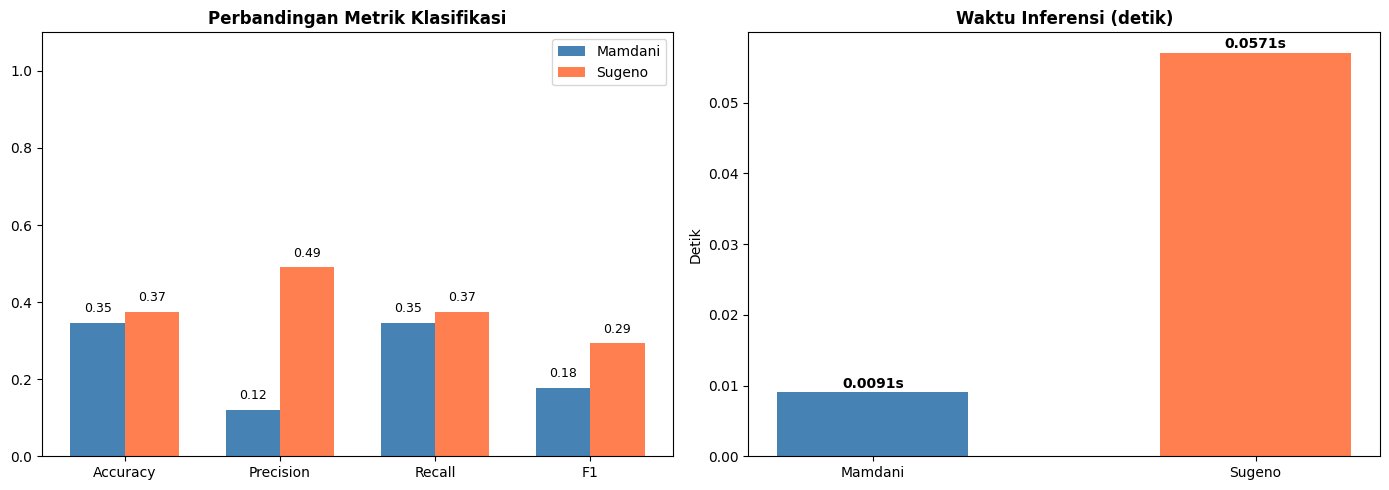

In [41]:
# ── 7.3 Perbandingan Metrik & Waktu Inferensi ─────────────────

# Pengaman: Jika FIS Sugeno belum dijalankan, kita buatkan data tiruan/kosong
# supaya kode tidak error saat kamu ingin melihat hasil Mamdani terlebih dahulu.
if 'results_sugeno' not in locals():
    results_sugeno = {'model': 'FIS SUGENO', 'accuracy': 0, 'precision': 0, 'recall': 0, 'f1': 0}
    t_sugeno = 0.0

# Membuat DataFrame perbandingan
list_data = [
    {**results_mamdani, 'inference_time_s': t_mamdani},
    {**results_sugeno,  'inference_time_s': t_sugeno},
]
comparison_df = pd.DataFrame(list_data).set_index('model')

print('\n=== TABEL PERBANDINGAN MAMDANI vs SUGENO ===')
print(comparison_df.to_string())

# ── Membuat Grafik Bar Chart ─────────────────────────────────
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Grafik 1: Metrik Klasifikasi
bars1 = axes[0].bar(x - width/2, comparison_df.loc['FIS MAMDANI', metrics],
                     width, label='Mamdani', color='steelblue')
bars2 = axes[0].bar(x + width/2, comparison_df.loc['FIS SUGENO', metrics],
                     width, label='Sugeno', color='coral')

axes[0].set_xticks(x)
axes[0].set_xticklabels([m.capitalize() for m in metrics])
axes[0].set_ylim(0, 1.1) # Diberi ruang sedikit di atas agar teks tidak mentok
axes[0].set_title('Perbandingan Metrik Klasifikasi', fontweight='bold')
axes[0].legend()

# Tambahkan angka di atas batang grafik metrik
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)


# Plot Grafik 2: Waktu Inferensi
waktu_bars = axes[1].bar(['Mamdani', 'Sugeno'], [t_mamdani, t_sugeno],
                         color=['steelblue', 'coral'], width=0.5)
axes[1].set_title('Waktu Inferensi (detik)', fontweight='bold')
axes[1].set_ylabel('Detik')

# Tambahkan angka di atas batang grafik waktu
for bar in waktu_bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + (t_mamdani*0.02 if t_mamdani > 0 else 0.1),
                 f'{yval:.4f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('eval_perbandingan.png', dpi=150)
plt.show()

## 🖥️ 8. Demo Interaktif AeroForecast

In [43]:
# Pastikan label_map tersedia (Berjaga-jaga jika sel evaluasi belum dijalankan)
label_map = {0: 'Beli Sekarang', 1: 'Pertimbangkan', 2: 'Tunggu'}

# ── Demo prediksi satu penerbangan ────────────────────────────

def aeroforecast_predict(airline=None, flight_class='Economy',
                          days_left_input=14, duration_input=10.0,
                          stops_input='one', price_input=None):
    """
    Demo AeroForecast: masukkan parameter penerbangan,
    dapatkan rekomendasi dari Mamdani (dan Sugeno jika ada).
    """
    # 1. Hitung price_ratio dengan pengaman DataFrame
    pr = 0.4  # Default awal
    if price_input is not None and flight_class in ['Economy', 'Business']:
        try:
            # CATATAN: Ubah 'df_clean' menjadi 'data' jika kamu sudah me-rename variabelmu!
            stats = df_clean[df_clean['class'] == flight_class]['price']

            if not stats.empty:
                p_min, p_max = stats.min(), stats.max()
                pr = (price_input - p_min) / (p_max - p_min + 1e-9)
                pr = float(np.clip(pr, 0, 1))
        except NameError:
            # Jika df_clean tidak ada, diam-diam gunakan nilai default
            pass

    # 2. Prediksi Mamdani
    try:
        pred_m = mamdani_predict(days_left_input, pr, duration_input)
    except Exception:
        pred_m = 1  # Fallback ke 'Pertimbangkan'

    # 3. Prediksi Sugeno (Dilengkapi pengaman NameError)
    try:
        pred_s = sugeno_infer(days_left_input, pr, duration_input)
        status_sugeno = label_map[pred_s]
    except NameError:
        # Jika belum membuat blok kode Sugeno, tangkap errornya
        status_sugeno = "Belum Tersedia"

    # 4. Cetak Hasil
    print('=' * 55)
    print('  ✈️  AeroForecast — Smart Booking Assistant')
    print('=' * 55)
    print(f'  Maskapai    : {airline if airline else "-"}')
    print(f'  Kelas       : {flight_class}')
    print(f'  Sisa Hari   : {days_left_input} hari')
    print(f'  Durasi      : {duration_input} jam')
    print(f'  Stops       : {stops_input}')
    print(f'  Harga       : {price_input if price_input else "N/A"} INR')
    print(f'  Price Ratio : {pr:.2f}')
    print('-' * 55)
    print(f'  🔵 Mamdani  → {label_map[pred_m]}')
    print(f'  🟠 Sugeno   → {status_sugeno}')
    print('=' * 55)


# ─── Contoh penggunaan ───────────────────────────────────────
aeroforecast_predict(
    airline       = 'IndiGo',
    flight_class  = 'Economy',
    days_left_input  = 14,
    duration_input= 8.5,
    stops_input   = 'one',
    price_input   = 4500
)

print()
aeroforecast_predict(
    airline       = 'Air India',
    flight_class  = 'Business',
    days_left_input  = 3,
    duration_input= 14.0,
    stops_input   = 'two_or_more',
    price_input   = 95000
)

  ✈️  AeroForecast — Smart Booking Assistant
  Maskapai    : IndiGo
  Kelas       : Economy
  Sisa Hari   : 14 hari
  Durasi      : 8.5 jam
  Stops       : one
  Harga       : 4500 INR
  Price Ratio : 0.40
-------------------------------------------------------
  🔵 Mamdani  → Pertimbangkan
  🟠 Sugeno   → Beli Sekarang

  ✈️  AeroForecast — Smart Booking Assistant
  Maskapai    : Air India
  Kelas       : Business
  Sisa Hari   : 3 hari
  Durasi      : 14.0 jam
  Stops       : two_or_more
  Harga       : 95000 INR
  Price Ratio : 0.40
-------------------------------------------------------
  🔵 Mamdani  → Pertimbangkan
  🟠 Sugeno   → Tunggu
